In [1]:
import cmasher as cmr

import scienceplots
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp

import cmbo
from IPython.display import display

from plot_stacked import *

COLORS = [
    "#25ced1",  # robin-egg-blue
    "#ef476f",  # bright-pink-crayola
    "#731dd8",  # french-violet
    "#522b29",  # caput-mortuum
    "#157f1f",  # office-green
]

%load_ext autoreload
%autoreload 2

/Users/rstiskalek/Projects/CMBOlympics/venv_cmbo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Single simulation results file

In [2]:
cfg = cmbo.utils.load_config("/Users/rstiskalek/Projects/CMBOlympics/scripts/config.toml")
res_cb1 = load_mass_bin_results(cfg, "csiborg1")
res_cb2 = load_mass_bin_results(cfg, "csiborg2")
res_manti = load_mass_bin_results(cfg, "manticore")


### Stacked 1D profiles per mass bin

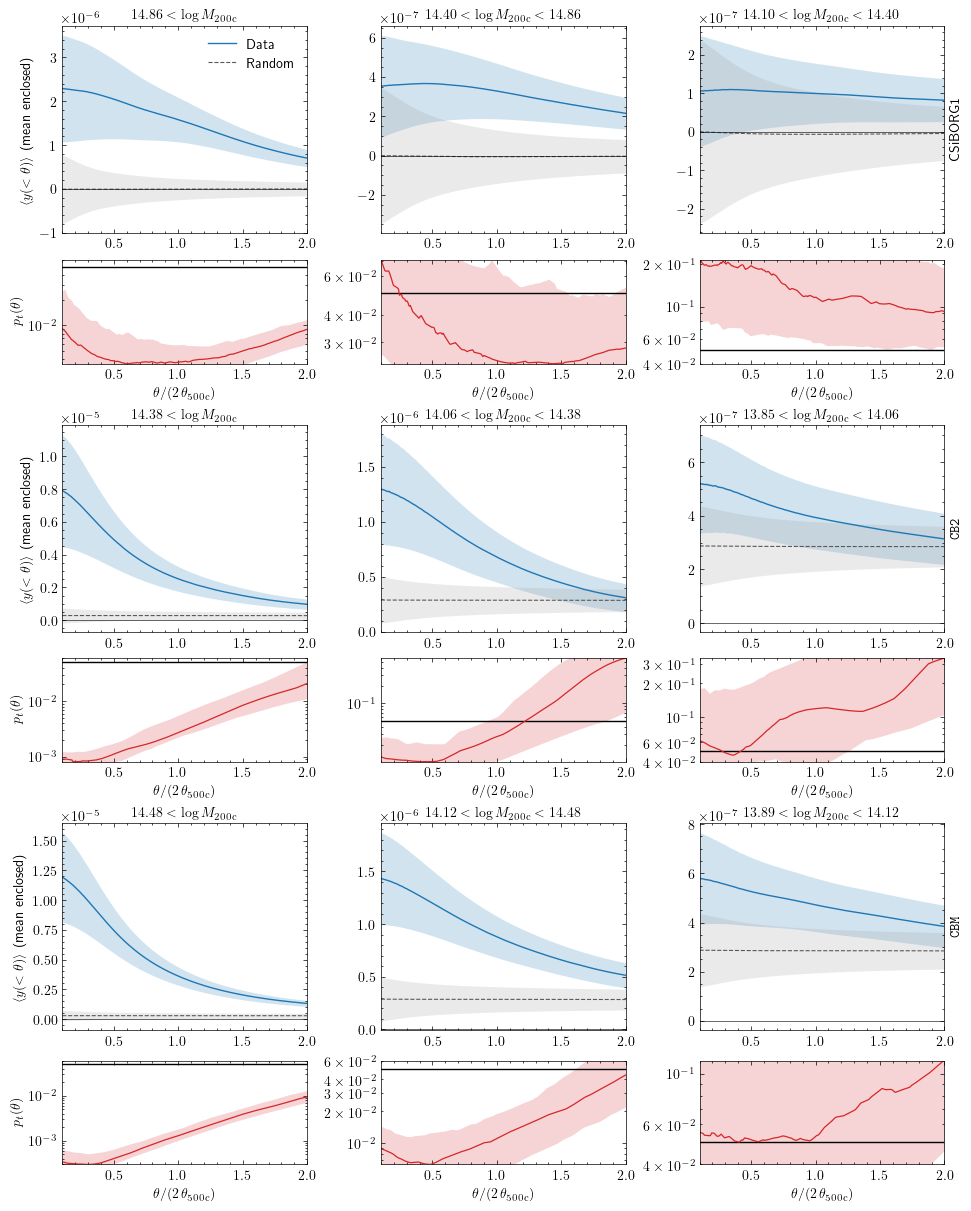

In [3]:
fig, axs = plot_stacked_profiles(
    [res_cb1, res_cb2, res_manti], nbins=3, simulation=None,
    row_labels=["CSiBORG1", "CSiBORG2", "Manticore"],
    theta500_scale=2,
    )
fig.savefig("/Users/rstiskalek/Downloads/stacked_many.png", dpi=450)

display(fig)

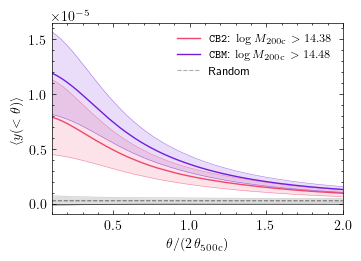

In [4]:
fig, axs = plot_stacked_profiles_overlay(
    [res_cb2, res_manti], nbins=1,
    simulation=None, theta500_scale=2,
    suite_labels=[r"\texttt{CB2}", r"\texttt{CBM}"],
    colors=COLORS[1:]
    )

fig.savefig("/Users/rstiskalek/Downloads/stacked_profiles.pdf", dpi=450)
display(fig)

### Stacked 2D profiles per mass bin

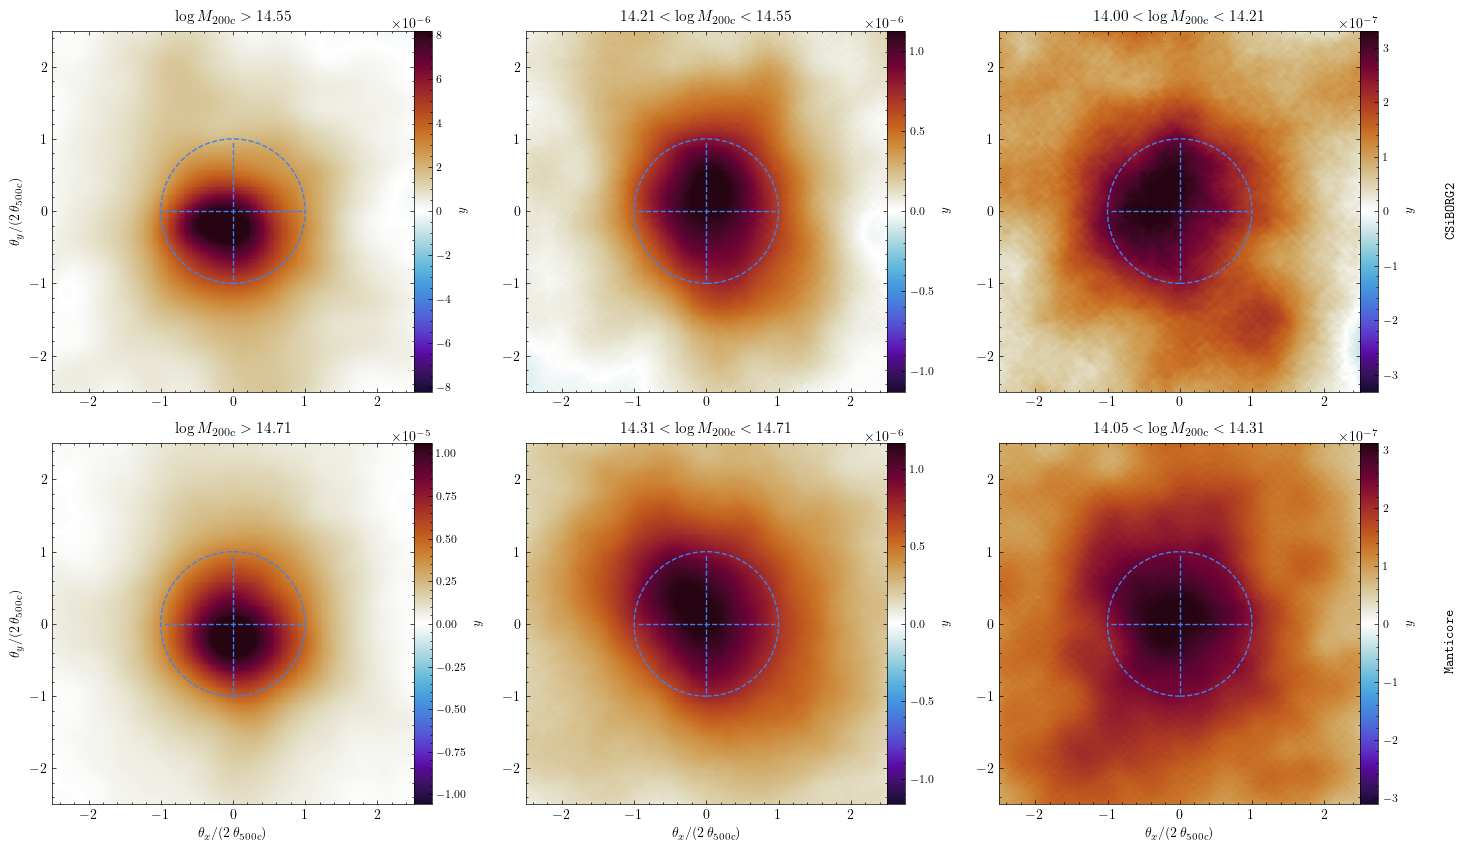

In [23]:
fig, axs = plot_cutout_maps(
    [res_cb2, res_manti], nbins=3, mode="stack", cmap=cmr.fusion_r,
    theta500_scale=2,
    # row_labels=["CSiBORG1", "CSiBORG2", "Manticore"],)
    row_labels=[r"\texttt{CSiBORG2}", r"\texttt{Manticore}"],
)
fig.savefig("/Users/rstiskalek/Downloads/projections_2d.pdf", dpi=450)
display(fig)